## PC-Lab 4 - Predicting stock returns with linear and tree models
### Henricus Bracht, Erdem Bayrakcioglu, Leonard Fischbach
### Executive Summary

#### Approach

- We predict **5-, 20-, and 60-day returns** with linear and tree models, then invest $100 in four stocks.

#### Findings

- Market and price signals help longer-horizon OLS forecasts; Lab 3 attention does not.
- Tree portfolios beat both buy-and-hold benchmarks.

## Imports and Load Data

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid
from scipy.optimize import minimize
import statsmodels.api as sm

RANDOM_SEED = 42
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
INITIAL_WEALTH = 100.0
FEE_RATE = 0.0001  # 1 basis point = 0.01%
N_RANDOM_PORTFOLIOS = 1000

# Validation winners from the extended-feature playground below.
TREE_CONFIGS = {
    5: {
        "Random Forest": {"n_estimators": 200, "max_depth": 2, "min_samples_leaf": 20, "max_features": 1.0},
        "Boosted trees": {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 3, "min_samples_leaf": 20}
    },
    20: {
        "Random Forest": {"n_estimators": 200, "max_depth": 2, "min_samples_leaf": 20, "max_features": 0.8},
        "Boosted trees": {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 1, "min_samples_leaf": 100}
    },
    60: {
        "Random Forest": {"n_estimators": 100, "max_depth": 2, "min_samples_leaf": 20, "max_features": 1.0},
        "Boosted trees": {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 1, "min_samples_leaf": 20}
    }
}

def make_tree(family, params):
    if family == "Random Forest":
        return RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=1, **params)
    return GradientBoostingRegressor(random_state=RANDOM_SEED, **params)
LAB_DIR = Path.cwd() if (Path.cwd() / 'Data_PCLab4_Stock_Price.csv').exists() else Path.cwd() / '#4'


#### Normalize prices and volumes and calculate daily returns

In [2]:
price_df = pd.read_csv(LAB_DIR / 'Data_PCLab4_Stock_Price.csv')
vol_df = pd.read_csv(LAB_DIR / 'Data_PCLab4_Stock_Volume.csv')

# Validate date order and alignment before constructing any returns.
for frame in (price_df, vol_df):
    frame["Date"] = pd.to_datetime(frame["Date"])
    frame.sort_values("Date", inplace=True, ignore_index=True)
    assert frame["Date"].is_unique
    assert frame.drop(columns="Date").notna().all().all()
    assert (frame.drop(columns="Date") > 0).all().all()
assert price_df["Date"].equals(vol_df["Date"])

price_norm_df = price_df.copy()
for col in price_norm_df.columns[1:]:
    price_norm_df[col] = (
        price_norm_df[col] / price_norm_df[col].iloc[0] * 100
    )

vol_norm_df = vol_df.copy()
for col in vol_norm_df.columns[1:]:
    vol_norm_df[col] = (
        vol_norm_df[col] / vol_norm_df[col].iloc[0] * 100
    )

daily_returns_df = price_df.copy()
stocks = [col for col in price_df.columns if col != "Date"]
daily_returns_df[stocks] = price_df[stocks].pct_change() * 100

vol_change_df = vol_df.copy()
stocks = [col for col in vol_df.columns if col != "Date"]
vol_change_df[stocks] = vol_df[stocks].pct_change() * 100

dfs = {
    "Price": price_df,
    "Volume": vol_df,
    "Normalized Price": price_norm_df,
    "Normalized Volume": vol_norm_df,
    "Daily Returns": daily_returns_df,
    "Daily Volume Change": vol_change_df
}

for name, df in dfs.items():
    print(name)
    display(df.head())


Price


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


Volume


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,53146800,3934500,26511100,17891100,5385800,6881000,729300,3764400,4019890000
1,2012-01-13,56505400,4641100,22096800,16621800,4753500,5279200,5500400,4631800,3692370000
2,2012-01-17,60724300,3700100,23500200,15480800,5644500,6003400,4651600,3832800,4010490000
3,2012-01-18,69197800,4189500,22015000,18387600,7473500,4600600,1260200,5544000,4096160000
4,2012-01-19,65434600,5397300,25524000,14022900,7096000,8567200,1246300,12657800,4465890000


Normalized Price


...

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2012-01-13,106.319477,117.959080,83.349239,92.905411,88.259869,76.721407,754.202660,123.042185,91.852513
2,2012-01-17,114.257679,94.042445,88.642870,86.527938,104.803372,87.246040,637.817085,101.817023,99.766163
3,2012-01-18,130.201254,106.481128,83.040689,102.775123,138.763044,66.859468,172.795832,147.274466,101.897316
4,2012-01-19,123.120489,137.178803,96.276654,78.379194,131.753871,124.505159,170.889894,336.250133,111.094831


Daily Returns


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-13,-0.374946,-1.205144,-0.166006,1.813685,1.415339,-0.769869,-19.327430,-0.738516,-0.494792
2,2012-01-17,1.164812,0.857909,0.598603,-0.809717,1.815943,0.468852,16.717854,0.574410,0.355295
3,2012-01-18,1.038382,-0.239234,0.264463,3.918367,4.282725,0.594448,0.789470,0.688856,1.110793
4,2012-01-19,-0.316937,0.666134,0.296736,0.549882,2.644634,-0.303752,-0.186494,1.052283,0.493866


Daily Volume Change


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-13,6.319477,17.959080,-16.650761,-7.094589,-11.740131,-23.278593,654.202660,23.042185,-8.147487
2,2012-01-17,7.466366,-20.275366,6.351146,-6.864479,18.744083,13.717988,-15.431605,-17.250313,8.615605
3,2012-01-18,13.954051,13.226670,-6.319946,18.776807,32.403224,-23.366759,-72.908247,44.646212,2.136148
4,2012-01-19,-5.438323,28.829216,15.939132,-23.737192,-5.051181,86.219189,-1.103000,128.315296,9.026259


We scale each price and volume series to **100 on the first date** and calculate daily returns.

## Task 1 - Basic Manipulation and Descriptive Statistics

### Major Findings

- **TSLA** has the highest total return (**4,765%**) and volatility (**54.5%**); **IBM** loses **29.8%** over the sample.
- **AAPL** has the highest average stock volume (**58 million shares daily**). S&P 500 reported volume peaks near **9 billion units**, but index and stock volumes are not directly comparable.
- TSLA's volume rises sharply around 2014. Daily stock returns average **0.089%** with **2.165%** standard deviation; return–volume-change correlations are weak.

### 1.1 Stock Price Development

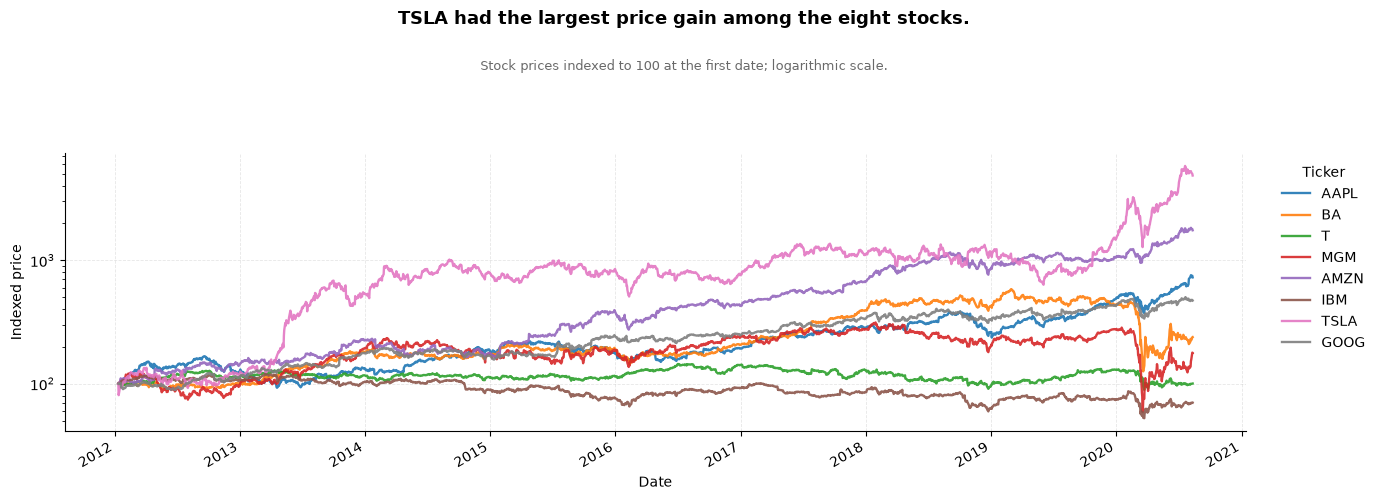

In [3]:
stocks = [c for c in price_norm_df.columns if c not in ["Date", "sp500"]]
colors = plt.cm.tab10.colors

def set_plot_titles(fig, takeaway, subtitle):
    fig.suptitle(takeaway, fontsize=13, fontweight="bold", y=0.99)
    fig.text(0.5, 0.87, subtitle, ha="center", color="dimgray", fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, 0.80))

def style_time_series(ax, takeaway, subtitle, ylabel, legend_title="Ticker"):
    ax.set(xlabel="Date", ylabel=ylabel)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.3)
    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.figure.autofmt_xdate()
    set_plot_titles(ax.figure, takeaway, subtitle)

def plot_stocks(frame, takeaway, subtitle, ylabel, linewidth=1.7, formatter=None, log=False):
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, stock in enumerate(stocks):
        ax.plot(frame["Date"], frame[stock], label=stock, color=colors[i % len(colors)],
                linewidth=linewidth, alpha=0.9)
    style_time_series(ax, takeaway, subtitle, ylabel)
    if formatter:
        ax.yaxis.set_major_formatter(formatter)
    if log:
        ax.set_yscale("log")
    plt.show()

plot_stocks(price_norm_df, "TSLA had the largest price gain among the eight stocks.",
            "Stock prices indexed to 100 at the first date; logarithmic scale.",
            "Indexed price", log=True)

### 1.2 Volume Development (raw and normalized)

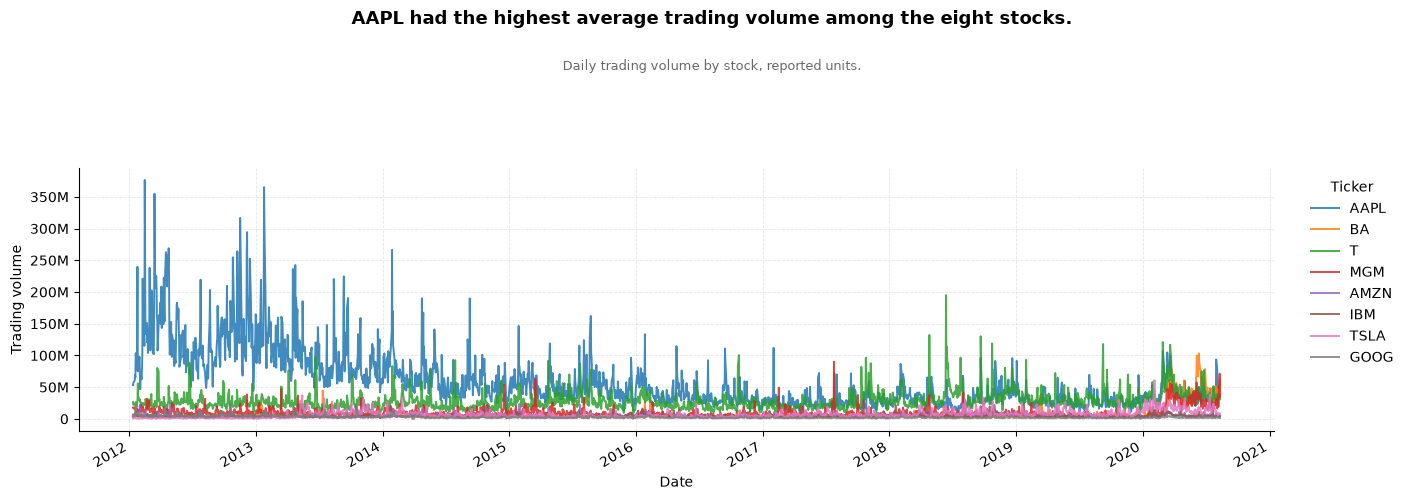

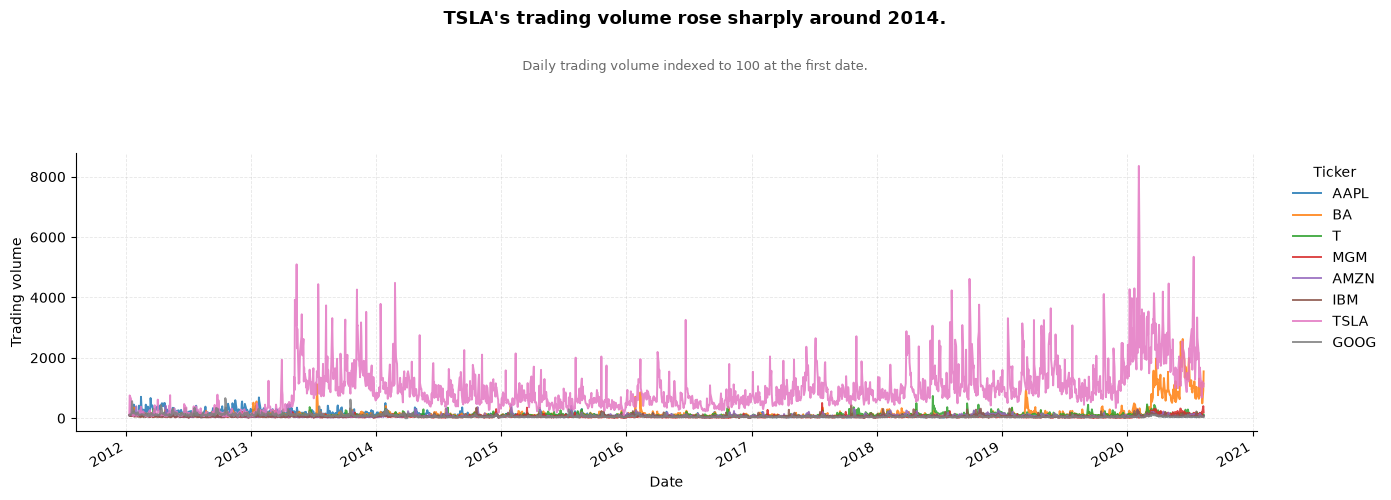

In [4]:
def millions(x, pos):
    for threshold, suffix in [(1e9, "B"), (1e6, "M"), (1e3, "K")]:
        if abs(x) >= threshold:
            return f"{x / threshold:.1f}{suffix}" if threshold == 1e9 else f"{x / threshold:.0f}{suffix}"
    return f"{x:.0f}"

for frame, takeaway, subtitle, formatter in [
    (vol_df, "AAPL had the highest average trading volume among the eight stocks.",
     "Daily trading volume by stock, reported units.", FuncFormatter(millions)),
    (vol_norm_df, "TSLA's trading volume rose sharply around 2014.",
     "Daily trading volume indexed to 100 at the first date.", None)
]:
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, stock in enumerate(stocks):
        ax.plot(frame["Date"], frame[stock], label=stock, color=colors[i % len(colors)],
                linewidth=1.4, alpha=0.85)
    style_time_series(ax, takeaway, subtitle, "Trading volume")
    if formatter:
        ax.yaxis.set_major_formatter(formatter)
    plt.show()

### 1.3 Daily returns

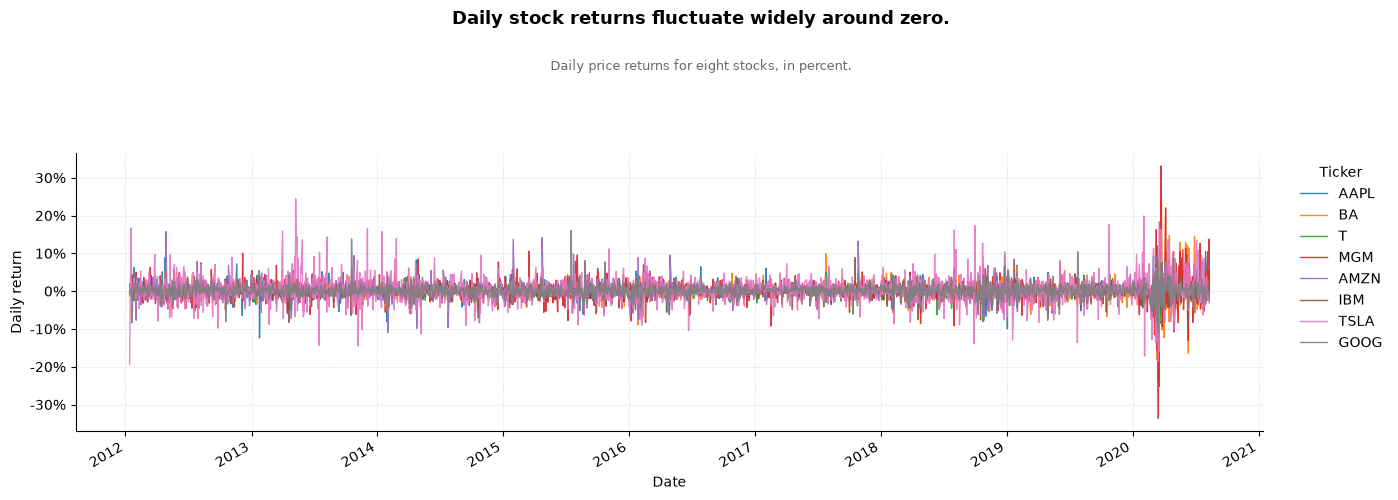

In [5]:
plot_stocks(daily_returns_df, "Daily stock returns fluctuate widely around zero.",
            "Daily price returns for eight stocks, in percent.", "Daily return", linewidth=1.0,
            formatter=FuncFormatter(lambda x, pos: f"{x:.0f}%"))

### 1.4 Summary statistics

In [6]:
summary_rows = []

stocks = [col for col in price_norm_df.columns
          if col not in ["Date"]]

for stock in stocks:

    returns = daily_returns_df[stock].dropna()
    volume = vol_df[stock].dropna()
    prices = price_df[stock].dropna()

    # Total return over the full sample
    total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

    summary_rows.append({
        "Security": stock,

        # Volume statistics
        "Avg Volume": volume.mean(),
        "Median Volume": volume.median(),
        "Max Volume": volume.max(),
        "Std Volume": volume.std(),

        # Return statistics
        "Avg Daily Return (%)": returns.mean(),
        "Median Daily Return (%)": returns.median(),
        "Std Daily Return (%)": returns.std(),
        "Annualized Volatility (%)": returns.std() * np.sqrt(252),
        "Min Daily Return (%)": returns.min(),
        "Max Daily Return (%)": returns.max(),

        "Positive Days (%)": (returns > 0).mean() * 100,
        "Skewness": returns.skew(),

        # Full-period performance
        "Total Return (%)": total_return
    })

summary_stats = pd.DataFrame(summary_rows).set_index("Security")


#Construct Overall Statistics:
individual_stocks = [s for s in stocks if s != "sp500"]

# Pool all stock-day observations
all_returns = daily_returns_df[individual_stocks].stack().dropna()
all_volumes = vol_df[individual_stocks].stack().dropna()

# Equal-weight buy-and-hold portfolio:
# normalize each stock to 1 at the beginning, then average across stocks
normalized_prices = (
    price_df[individual_stocks]
    / price_df[individual_stocks].iloc[0]
)

equal_weight_portfolio = normalized_prices.mean(axis=1)

overall_total_return = (
    equal_weight_portfolio.iloc[-1]
    / equal_weight_portfolio.iloc[0]
    - 1
) * 100

overall_row = pd.DataFrame({
    "Avg Volume": [all_volumes.mean()],
    "Median Volume": [all_volumes.median()],
    "Max Volume": [all_volumes.max()],
    "Std Volume": [all_volumes.std()],
    "Avg Daily Return (%)": [all_returns.mean()],
    "Median Daily Return (%)": [all_returns.median()],
    "Std Daily Return (%)": [all_returns.std()],
    "Annualized Volatility (%)": [all_returns.std() * np.sqrt(252)],
    "Min Daily Return (%)": [all_returns.min()],
    "Max Daily Return (%)": [all_returns.max()],
    "Positive Days (%)": [(all_returns > 0).mean() * 100],
    "Skewness": [all_returns.skew()], 
    "Total Return (%)": [overall_total_return]
}, index=["Overall (excl. S&P500)"])

summary_stats = pd.concat([summary_stats, overall_row])

In [7]:
summary_display = summary_stats.copy()

volume_cols = [
    "Avg Volume",
    "Median Volume",
    "Max Volume",
    "Std Volume"
]

# Convert volume to millions
summary_display[volume_cols] = summary_display[volume_cols] / 1_000_000

summary_display = summary_display.rename(columns={
    "Avg Volume": "Avg Volume (M)",
    "Median Volume": "Median Volume (M)",
    "Max Volume": "Max Volume (M)",
    "Std Volume": "Std Volume (M)"
})

summary_display.style.format({
    "Avg Volume (M)": "{:,.2f}",
    "Median Volume (M)": "{:,.2f}",
    "Max Volume (M)": "{:,.2f}",
    "Std Volume (M)": "{:,.2f}",
    "Avg Daily Return (%)": "{:.3f}%",
    "Median Daily Return (%)": "{:.3f}%",
    "Std Daily Return (%)": "{:.3f}%",
    "Annualized Volatility (%)": "{:.2f}%",
    "Min Daily Return (%)": "{:.2f}%",
    "Max Daily Return (%)": "{:.2f}%",
    "Total Return (%)": "{:.2f}%"
}).set_caption(
    "Summary Statistics: Stock Returns and Trading Volume"
)

,Avg Volume (M),Median Volume (M),Max Volume (M),Std Volume (M),Avg Daily Return (%),Median Daily Return (%),Std Daily Return (%),Annualized Volatility (%),Min Daily Return (%),Max Daily Return (%),Positive Days (%),Skewness,Total Return (%)
AAPL,58.20,42.09,376.53,45.68,0.108%,0.083%,1.776%,28.20%,-12.86%,11.98%,52.594995,-0.097865,626.76%
BA,6.42,3.99,103.21,9.71,0.066%,0.078%,2.260%,35.88%,-23.85%,24.32%,52.224282,0.227336,138.55%
T,28.32,24.86,195.08,14.29,0.008%,0.060%,1.265%,20.08%,-9.24%,10.02%,52.363299,-0.497455,0.27%
MGM,9.85,7.90,90.10,7.30,0.065%,0.112%,2.747%,43.61%,-33.61%,33.11%,51.899907,0.007458,77.25%
AMZN,4.10,3.49,23.86,2.29,0.151%,0.117%,1.928%,30.61%,-11.00%,15.75%,53.938832,0.620135,1651.08%
IBM,4.45,3.83,30.49,2.46,-0.006%,0.022%,1.431%,22.72%,-12.85%,11.30%,50.880445,-0.464064,-29.80%
TSLA,7.00,5.58,60.94,5.78,0.239%,0.117%,3.431%,54.46%,-19.33%,24.40%,51.621872,0.488056,4765.10%
GOOG,2.50,1.81,24.98,1.93,0.084%,0.061%,1.586%,25.18%,-11.10%,16.05%,52.594995,0.634918,371.97%
sp500,"3,680.73","3,526.89","9,044.69",862.27,0.049%,0.059%,1.049%,16.65%,-11.98%,9.38%,54.680259,-0.651611,157.33%
Overall (excl. S&P500),15.11,5.37,376.53,25.20,0.089%,0.075%,2.165%,34.37%,-33.61%,33.11%,52.264829,0.378525,950.15%


### 1.5 Correlation between change in price and change in volume

In [8]:
correlations = pd.DataFrame({
    "Return-Volume Correlation": [
        daily_returns_df[stock].corr(vol_change_df[stock])
        for stock in stocks
    ]
}, index=stocks)

# Add the overall correlation
all_returns = daily_returns_df[stocks].stack()
all_vol_changes = vol_change_df[stocks].stack()
overall_corr = all_returns.corr(all_vol_changes)
correlations.loc['Overall'] = overall_corr

correlations

,Return-Volume Correlation
AAPL,-0.114204
BA,-0.071670
T,-0.139598
MGM,0.025558
AMZN,0.070281
IBM,-0.081546
TSLA,0.045621
GOOG,-0.024028
sp500,-0.102456
Overall,-0.013952


## Task 2 - Train and Test samples + Ridge regression

### 2.1 Build the feature dataframe for OLS and Ridge

#### Approach

- We combine eight stocks, excluding the S&P 500. Six predictors measure past **5-, 20-, and 60-day returns and volume changes**. The targets are the next **5-, 20-, and 60-day stock returns**, in percentage points.

#### Findings

- The datasets contain **16,752, 16,632, and 16,312 rows**.

In [9]:
# 1. Individual stocks only

model_stocks = [
    col for col in price_df.columns
    if col not in ["Date", "sp500"]
]

# 2. Convert price and volume data to long format

price_long = price_df.melt(
    id_vars="Date",
    value_vars=model_stocks,
    var_name="Stock",
    value_name="Price"
)

volume_long = vol_df.melt(
    id_vars="Date",
    value_vars=model_stocks,
    var_name="Stock",
    value_name="Volume"
)

panel_df = pd.merge(
    price_long,
    volume_long,
    on=["Date", "Stock"],
    how="inner"
)

panel_df = panel_df.sort_values(
    ["Stock", "Date"]
).reset_index(drop=True)


# 3. Create all 6 predictor variables

grouped = panel_df.groupby("Stock")

lookback_windows = [5, 20, 60]

for h in lookback_windows:

    # Past cumulative stock return over h trading days
    panel_df[f"Past_Return_{h}d"] = (
        panel_df["Price"] / grouped["Price"].shift(h) - 1
    ) * 100

    # Past percentage change in trading volume over h trading days
    panel_df[f"Past_Volume_Change_{h}d"] = (
        panel_df["Volume"] / grouped["Volume"].shift(h) - 1
    ) * 100


# 4. Create the 3 future return targets

forecast_horizons = [5, 20, 60]

for h in forecast_horizons:

    panel_df[f"Future_Return_{h}d"] = (
        grouped["Price"].shift(-h) / panel_df["Price"] - 1
    ) * 100

    # Date at which the future return period ends
    panel_df[f"Target_Date_{h}d"] = grouped["Date"].shift(-h)


# 5. Feature list

feature_cols = [
    "Past_Return_5d",
    "Past_Return_20d",
    "Past_Return_60d",
    "Past_Volume_Change_5d",
    "Past_Volume_Change_20d",
    "Past_Volume_Change_60d"
]


# 6. Build one dataframe per forecast horizon

model_dfs = {}

for h in forecast_horizons:

    target_col = f"Future_Return_{h}d"
    target_date_col = f"Target_Date_{h}d"

    df = panel_df[
        ["Date", "Stock"]
        + feature_cols
        + [target_col, target_date_col]
    ].dropna().copy()

    model_dfs[h] = df

    print(f"\n{h}-day prediction dataframe:")
    display(df.head())
    print(f"Observations: {len(df):,}")


5-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_5d,Target_Date_5d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-2.981992,2012-04-17
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-2.852125,2012-04-18
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-5.673041,2012-04-19
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,-5.328550,2012-04-20
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,-1.453130,2012-04-23


Observations: 16,752

20-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_20d,Target_Date_20d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-9.588826,2012-05-08
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-9.105716,2012-05-09
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-8.389937,2012-05-10
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,-6.364519,2012-05-11
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,-3.776746,2012-05-14


Observations: 16,632

60-day prediction dataframe:


,Date,Stock,Past_Return_5d,Past_Return_20d,Past_Return_60d,Past_Volume_Change_5d,Past_Volume_Change_20d,Past_Volume_Change_60d,Future_Return_60d,Target_Date_60d
60,2012-04-10,AAPL,1.585761,13.847833,49.135013,48.696051,118.454124,318.522470,-2.943800,2012-07-05
61,2012-04-11,AAPL,-0.495767,10.227076,49.162720,-16.529053,0.833691,208.207180,-3.244976,2012-07-06
62,2012-04-12,AAPL,-0.246673,5.629426,46.637621,7.217694,-56.701597,152.920495,-1.425886,2012-07-09
63,2012-04-13,AAPL,-4.489647,3.359175,41.043082,34.047635,-25.874670,210.575192,0.492381,2012-07-10
64,2012-04-16,AAPL,-8.817562,-0.929004,35.623616,75.853069,27.292863,301.464516,4.188715,2012-07-11


Observations: 16,312


### 2.2 Train-Test Split

#### Approach

- We train on the first **75% of dates** and test on the last **25%**. Targets cannot cross the split; scaling uses training data only.

In [10]:
# Chronological 75% / 25% split

all_dates = np.sort(panel_df["Date"].unique())

split_index = int(len(all_dates) * 0.75)
split_date = pd.Timestamp(all_dates[split_index])

print(f"Train/Test cutoff date: {split_date.date()}")


X_train_scaled = {}
X_test_scaled = {}

y_train = {}
y_test = {}

train_data = {}
test_data = {}

for h in forecast_horizons:

    df = model_dfs[h].copy()

    target_col = f"Future_Return_{h}d"
    target_date_col = f"Target_Date_{h}d"

    # Prevent future-return window from crossing into test period
    train_df = df[
        df[target_date_col] < split_date
    ].copy()

    test_df = df[
        df["Date"] >= split_date
    ].copy()

    train_data[h] = train_df
    test_data[h] = test_df

    # Fit MinMaxScaler on training features only
    scaler = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled[h] = pd.DataFrame(
        scaler.fit_transform(train_df[feature_cols]),
        columns=feature_cols,
        index=train_df.index
    )

    X_test_scaled[h] = pd.DataFrame(
        scaler.transform(test_df[feature_cols]),
        columns=feature_cols,
        index=test_df.index
    )

    y_train[h] = train_df[target_col]
    y_test[h] = test_df[target_col]

    print(f"\n{h}-day horizon:")
    print(f"Training observations: {len(train_df):,}")
    print(f"Testing observations:  {len(test_df):,}")
    print(
        f"Train period: {train_df['Date'].min().date()} "
        f"to {train_df['Date'].max().date()}"
    )
    print(
        f"Test period:  {test_df['Date'].min().date()} "
        f"to {test_df['Date'].max().date()}"
    )


def r2_oos(y_true, y_pred):
    return 1 - (
        np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2)
        / np.sum(np.asarray(y_true) ** 2)
    )

def score_forecast(y_true, prediction):
    return {
        "R2_OOS (%)": 100 * r2_oos(y_true, prediction),
        "Test R2 (%)": 100 * r2_score(y_true, prediction),
        "RMSE (pp)": np.sqrt(mean_squared_error(y_true, prediction)),
        "Correct sign (%)": 100 * np.mean(np.sign(y_true) == np.sign(prediction))
    }


Train/Test cutoff date: 2018-06-20

5-day horizon:
Training observations: 12,432
Testing observations:  4,280
Train period: 2012-04-10 to 2018-06-12
Test period:  2018-06-20 to 2020-08-04

20-day horizon:
Training observations: 12,312
Testing observations:  4,160
Train period: 2012-04-10 to 2018-05-21
Test period:  2018-06-20 to 2020-07-14

60-day horizon:
Training observations: 11,992
Testing observations:  3,840
Train period: 2012-04-10 to 2018-03-23
Test period:  2018-06-20 to 2020-05-15


### 2.3 OLS models (5-, 20- and 60-day ahead)

#### Approach

- We fit OLS separately at each horizon. Test $R^2_{OOS}$ compares squared errors with a **zero-return forecast**; we also show conventional $R^2$ and MSE.

#### Findings

- OLS test $R^2_{OOS}$ is **0.54%, 0.69%, and 1.85%** (5/20/60 days). Conventional test $R^2$ is positive only at 5 days (**0.08%**).

#### 2.3.1 OLS MODEL: 5-DAY RETURN

In [11]:
h = 5

# statsmodels requires us to add the intercept manually
X_train_ols_5 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_5 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

# Fit OLS on training sample
ols_5 = sm.OLS(
    y_train[h],
    X_train_ols_5
).fit()

# Out-of-sample predictions
pred_ols_5 = ols_5.predict(X_test_ols_5)

# Evaluation
roos_ols_5 = r2_oos(y_test[h], pred_ols_5)
r2_test_ols_5 = r2_score(y_test[h], pred_ols_5)
mse_ols_5 = mean_squared_error(y_test[h], pred_ols_5)

print("OLS — 5-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_5.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_5:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_5:.4f}")
print(f"Test MSE:            {mse_ols_5:.4f}")

display(ols_5.summary())

OLS — 5-Day Return Prediction
In-sample R²:       0.0041
Out-of-sample R²:   0.0008
R²_OOS (Gu et al.): 0.0054
Test MSE:            50.6749


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Future_Return_5d   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.532
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           2.84e-09
Time:                        20:21:35   Log-Likelihood:                -34921.
No. Observations:               12432   AIC:                         6.986e+04
Df Residuals:                   12425   BIC:                         6.991e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.9742      0.233      4.183      0.000       0.518       1.431
Past_Return_5d            -4.2857      0.796     -5.387      0.000      -5.845      -2.726
Past_Return_20d            2.4337      0.799      3.046      0.002       0.868       4.000
Past_Return_60d            1.6062      0.655      2.450      0.014       0.321       2.891
Past_Volume_Change_5d     -3.3630      2.304     -1.460      0.144      -7.879       1.153
Past_Volume_Change_20d    -0.0223      2.592     -0.009      0.993      -5.103       5.058
Past_Volume_Change_60d     6.2169      2.694      2.307      0.021       0.935      11.498
==============================================================================
Omnibus:                     3128.043   Durbin-Watson:                   0.390
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            47477.280
Skew:                           0.795   Prob(JB):                         0.00
Kurtosis:                      12.441   Cond. No.                         82.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2.3.2 OLS MODEL: 20-DAY RETURN

In [12]:
h = 20

X_train_ols_20 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_20 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

ols_20 = sm.OLS(
    y_train[h],
    X_train_ols_20
).fit()

pred_ols_20 = ols_20.predict(X_test_ols_20)

roos_ols_20 = r2_oos(y_test[h], pred_ols_20)
r2_test_ols_20 = r2_score(y_test[h], pred_ols_20)
mse_ols_20 = mean_squared_error(y_test[h], pred_ols_20)

print("OLS — 20-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_20.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_20:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_20:.4f}")
print(f"Test MSE:            {mse_ols_20:.4f}")

display(ols_20.summary())

OLS — 20-Day Return Prediction
In-sample R²:       0.0075
Out-of-sample R²:   -0.0104
R²_OOS (Gu et al.): 0.0069
Test MSE:            197.0950


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Future_Return_20d   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     15.55
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           7.37e-18
Time:                        20:21:35   Log-Likelihood:                -43383.
No. Observations:               12312   AIC:                         8.678e+04
Df Residuals:                   12305   BIC:                         8.683e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1931      0.477     -0.405      0.686      -1.129       0.743
Past_Return_5d            -1.9658      1.632     -1.205      0.228      -5.164       1.233
Past_Return_20d            6.9047      1.637      4.218      0.000       3.696      10.114
Past_Return_60d            4.6823      1.344      3.483      0.000       2.047       7.317
Past_Volume_Change_5d     -7.5864      4.708     -1.611      0.107     -16.815       1.643
Past_Volume_Change_20d    11.0522      5.298      2.086      0.037       0.668      21.436
Past_Volume_Change_60d    19.3587      5.508      3.515      0.000       8.562      30.155
==============================================================================
Omnibus:                     6032.535   Durbin-Watson:                   0.107
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           139002.840
Skew:                           1.841   Prob(JB):                         0.00
Kurtosis:                      19.044   Cond. No.                         81.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2.3.3 OLS MODEL: 60-DAY RETURN

In [13]:
h = 60

X_train_ols_60 = sm.add_constant(
    X_train_scaled[h],
    has_constant="add"
)

X_test_ols_60 = sm.add_constant(
    X_test_scaled[h],
    has_constant="add"
)

ols_60 = sm.OLS(
    y_train[h],
    X_train_ols_60
).fit()

pred_ols_60 = ols_60.predict(X_test_ols_60)

roos_ols_60 = r2_oos(y_test[h], pred_ols_60)
r2_test_ols_60 = r2_score(y_test[h], pred_ols_60)
mse_ols_60 = mean_squared_error(y_test[h], pred_ols_60)

print("OLS — 60-Day Return Prediction")
print("=" * 45)
print(f"In-sample R²:       {ols_60.rsquared:.4f}")
print(f"Out-of-sample R²:   {r2_test_ols_60:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ols_60:.4f}")
print(f"Test MSE:            {mse_ols_60:.4f}")

display(ols_60.summary())

OLS — 60-Day Return Prediction
In-sample R²:       0.0220
Out-of-sample R²:   -0.0136
R²_OOS (Gu et al.): 0.0185
Test MSE:            672.2766


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Future_Return_60d   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     45.00
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           9.30e-55
Time:                        20:21:35   Log-Likelihood:                -50847.
No. Observations:               11992   AIC:                         1.017e+05
Df Residuals:                   11985   BIC:                         1.018e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1058      0.994     -0.106      0.915      -2.055       1.843
Past_Return_5d             1.1411      3.408      0.335      0.738      -5.539       7.822
Past_Return_20d           -2.2328      3.396     -0.657      0.511      -8.890       4.424
Past_Return_60d           34.5891      2.770     12.489      0.000      29.160      40.018
Past_Volume_Change_5d      5.3958      9.640      0.560      0.576     -13.500      24.292
Past_Volume_Change_20d    27.8804     10.851      2.569      0.010       6.611      49.150
Past_Volume_Change_60d    60.2069     11.287      5.334      0.000      38.082      82.332
==============================================================================
Omnibus:                    10652.626   Durbin-Watson:                   0.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           648059.820
Skew:                           4.029   Prob(JB):                         0.00
Kurtosis:                      38.100   Cond. No.                         80.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2.4 Ridge models (5-, 20- and 60-day ahead)

#### Approach

- Ridge uses the same scaled predictors with a coefficient-shrinking penalty of **$\alpha=1$**.

#### Findings

- Ridge test $R^2_{OOS}$ is **0.53%, 0.67%, and 1.72%** (5/20/60 days), slightly below OLS.

#### 2.4.1 RIDGE: 5-DAY RETURN

In [14]:
h = 5
alpha = 1.0

ridge_5 = Ridge(alpha=alpha)

ridge_5.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_5 = ridge_5.predict(
    X_test_scaled[h]
)

roos_ridge_5 = r2_oos(y_test[h], pred_ridge_5)
r2_train_ridge_5 = ridge_5.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_5 = r2_score(
    y_test[h],
    pred_ridge_5
)
mse_ridge_5 = mean_squared_error(
    y_test[h],
    pred_ridge_5
)

print("Ridge — 5-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_5:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_5:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_5:.4f}")
print(f"Test MSE:            {mse_ridge_5:.4f}")

ridge_coef_5 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_5.coef_
})

display(ridge_coef_5)

Ridge — 5-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0040
Out-of-sample R²:   0.0008
R²_OOS (Gu et al.): 0.0053
Test MSE:            50.6785


,Feature,Coefficient
0,Past_Return_5d,-4.081462
1,Past_Return_20d,2.309363
2,Past_Return_60d,1.624128
3,Past_Volume_Change_5d,-2.512351
4,Past_Volume_Change_20d,0.019456
5,Past_Volume_Change_60d,4.278971


#### 2.4.2 RIDGE: 20-DAY RETURN

In [15]:
h = 20
alpha = 1.0

ridge_20 = Ridge(alpha=alpha)

ridge_20.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_20 = ridge_20.predict(
    X_test_scaled[h]
)

roos_ridge_20 = r2_oos(y_test[h], pred_ridge_20)
r2_train_ridge_20 = ridge_20.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_20 = r2_score(
    y_test[h],
    pred_ridge_20
)
mse_ridge_20 = mean_squared_error(
    y_test[h],
    pred_ridge_20
)

print("Ridge — 20-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_20:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_20:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_20:.4f}")
print(f"Test MSE:            {mse_ridge_20:.4f}")

ridge_coef_20 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_20.coef_
})

display(ridge_coef_20)

Ridge — 20-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0074
Out-of-sample R²:   -0.0107
R²_OOS (Gu et al.): 0.0067
Test MSE:            197.1411


,Feature,Coefficient
0,Past_Return_5d,-1.763282
1,Past_Return_20d,6.702309
2,Past_Return_60d,4.740523
3,Past_Volume_Change_5d,-5.614022
4,Past_Volume_Change_20d,7.925390
5,Past_Volume_Change_60d,13.429049


#### 2.4.3 RIDGE: 60-DAY RETURN

In [16]:
h = 60
alpha = 1.0

ridge_60 = Ridge(alpha=alpha)

ridge_60.fit(
    X_train_scaled[h],
    y_train[h]
)

pred_ridge_60 = ridge_60.predict(
    X_test_scaled[h]
)

roos_ridge_60 = r2_oos(y_test[h], pred_ridge_60)
r2_train_ridge_60 = ridge_60.score(
    X_train_scaled[h],
    y_train[h]
)
r2_test_ridge_60 = r2_score(
    y_test[h],
    pred_ridge_60
)
mse_ridge_60 = mean_squared_error(
    y_test[h],
    pred_ridge_60
)

print("Ridge — 60-Day Return Prediction")
print("=" * 45)
print(f"Penalty α:           {alpha}")
print(f"In-sample R²:       {r2_train_ridge_60:.4f}")
print(f"Out-of-sample R²:   {r2_test_ridge_60:.4f}")
print(f"R²_OOS (Gu et al.): {roos_ridge_60:.4f}")
print(f"Test MSE:            {mse_ridge_60:.4f}")

ridge_coef_60 = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_60.coef_
})

display(ridge_coef_60)

Ridge — 60-Day Return Prediction
Penalty α:           1.0
In-sample R²:       0.0218
Out-of-sample R²:   -0.0149
R²_OOS (Gu et al.): 0.0172
Test MSE:            673.1690


,Feature,Coefficient
0,Past_Return_5d,1.139342
1,Past_Return_20d,-1.545903
2,Past_Return_60d,33.864086
3,Past_Volume_Change_5d,4.369988
4,Past_Volume_Change_20d,20.167891
5,Past_Volume_Change_60d,41.840504


### 2.5 Predicting the sign of returns

#### Approach

- We compare each predicted return's sign with the realized sign and an **always-positive** forecast.

#### Findings

- OLS is correct on **55.12%, 57.19%, and 56.59%** of test rows (5/20/60 days); Ridge is similar. Both trail the always-positive rates of **56.26%, 58.08%, and 58.57%**.

In [17]:
sign_report_df = pd.DataFrame([
    {"Model_name": f"{name}_{h}", "Values (%)": 100 * np.mean(np.sign(y_test[h]) == np.sign(prediction))}
    for name, predictions in [("OLS", {5: pred_ols_5, 20: pred_ols_20, 60: pred_ols_60}),
                              ("ridge", {5: pred_ridge_5, 20: pred_ridge_20, 60: pred_ridge_60})]
    for h in forecast_horizons
    for prediction in [predictions[h]]
] + [
    {"Model_name": f"always_positive_{h}", "Values (%)": 100 * np.mean(y_test[h] > 0)}
    for h in forecast_horizons
])
sign_report_df


,Model_name,Values (%)
0,OLS_5,55.116822
1,OLS_20,57.187500
2,OLS_60,56.588542
3,ridge_5,55.163551
4,ridge_20,57.187500
5,ridge_60,56.380208
6,always_positive_5,56.261682
7,always_positive_20,58.076923
8,always_positive_60,58.567708


### 2.6 Adding market information and simple price signals

#### Approach

- We add past **S&P 500 returns**, then a **20-day moving-average gap** and **20-day volatility**, to the six stock signals. We keep the same train/test split.
- We also check Ridge penalties from **0.01 to 100** on the original six signals; test comparisons do not select the penalty.

#### Findings

- Market signals raise OLS test $R^2_{OOS}$ to **0.92%, 3.97%, and 5.58%** (5/20/60 days). Adding trend and volatility gives **0.24%, 4.28%, and 17.41%**.
- Ridge **$\alpha=100$** improves the 20- and 60-day test scores over $\alpha=1$, but worsens 5 days. We retain $\alpha=1$ as the reference.

In [18]:
market_features = []
market = price_df[["Date", "sp500"]].copy()
for h in lookback_windows:
    col = f"Market_Return_{h}d"
    market[col] = market["sp500"].pct_change(h) * 100
    market_features.append(col)

enhanced_panel = panel_df.merge(market[["Date"] + market_features], on="Date", validate="many_to_one")
stock_groups = enhanced_panel.groupby("Stock", sort=False)["Price"]
enhanced_panel["MA_Gap_20d"] = (
    enhanced_panel["Price"] / stock_groups.transform(lambda x: x.rolling(20).mean()) - 1
) * 100
enhanced_panel["Volatility_20d"] = stock_groups.transform(
    lambda x: x.pct_change().rolling(20).std()
) * 100  # daily standard deviation, in percentage points

feature_sets = {
    "Original": feature_cols,
    "+ Market": feature_cols + market_features,
    "+ Market + trend/risk": feature_cols + market_features + ["MA_Gap_20d", "Volatility_20d"]
}
all_features = feature_sets["+ Market + trend/risk"]

# Fixed specifications, each fitted on the original 75% training sample.
# These test comparisons are descriptive; later trees retain the original six features.
feature_rows, ridge_rows = [], []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    target_date = f"Target_Date_{h}d"
    frame = enhanced_panel.dropna(subset=all_features + [target, target_date]).copy()
    assert np.isfinite(frame[all_features + [target]]).all().all()
    assert len(frame) == len(model_dfs[h])
    train = frame.loc[frame[target_date] < split_date]
    test = frame.loc[frame["Date"] >= split_date]
    assert train[target_date].max() < test["Date"].min()

    for name, columns in feature_sets.items():
        model = make_pipeline(MinMaxScaler(), LinearRegression())
        model.fit(train[columns], train[target])
        prediction = model.predict(test[columns])
        feature_rows.append({"Horizon": h, "Features": name,
                             **score_forecast(test[target], prediction)})

    # Show the effect of different penalties without replacing the alpha=1 baseline.
    for alpha in RIDGE_ALPHAS:
        model = make_pipeline(MinMaxScaler(), Ridge(alpha=alpha))
        model.fit(train[feature_cols], train[target])
        prediction = model.predict(test[feature_cols])
        ridge_rows.append({"Horizon": h, "Alpha": alpha,
                           **score_forecast(test[target], prediction)})

feature_results = pd.DataFrame(feature_rows)
ridge_results = pd.DataFrame(ridge_rows)
display(feature_results.round(3))
display(ridge_results.pivot(index="Alpha", columns="Horizon", values="R2_OOS (%)").round(3))


,Horizon,Features,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
0,5,Original,0.536,0.084,7.119,55.117
1,5,+ Market,0.923,0.472,7.105,54.930
2,5,+ Market + trend/risk,0.245,-0.209,7.129,54.883
3,20,Original,0.694,-1.044,14.039,57.188
4,20,+ Market,3.965,2.285,13.806,57.764
5,20,+ Market + trend/risk,4.285,2.610,13.783,57.380
6,60,Original,1.849,-1.357,25.928,56.589
7,60,+ Market,5.578,2.494,25.431,57.161
8,60,+ Market + trend/risk,17.413,14.715,23.784,58.516


Horizon,5,20,60
Alpha,,,
0.01,0.536,0.693,1.847
0.10,0.535,0.690,1.830
1.00,0.529,0.671,1.719
10.00,0.511,0.774,1.710
100.00,0.449,1.319,2.529


### 2.7 Can Lab 3 attention improve the section 2.6 OLS model?

#### Approach

- Lab 3 attention measures **recent unique-user interest relative to a baseline**, not sentiment. We match each forecast to the latest earlier monthly score, at most **35 days old**; ineligible scores and the 2017 data gap stay missing.
- We compare the full section 2.6 OLS with and without attention on **identical rows**.

#### Findings

- Attention changes test $R^2_{OOS}$ from **0.583% to 0.578%**, **5.543% to 5.442%**, and **14.523% to 14.113%** (5/20/60 days): no improvement.
- At 60 days, sign accuracy rises from **59.06% to 60.35%**. Attention covers about **95% of test rows**. Section 3.2 uses these rows; sections 3.1 and 4 use the full six-signal sample.

,Horizon,Train rows,Test rows,Train dates,Test dates,Test coverage (%)
0,5,7551,4092,994,535,95.61
1,20,7431,3972,979,520,95.48
2,60,7111,3652,939,480,95.10


,Horizon,Model,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
0,5,"OLS (2.6), matched sample",0.583,0.080,7.198,51.417
1,5,OLS (2.6) + attention,0.578,0.075,7.198,51.613
2,20,"OLS (2.6), matched sample",5.543,3.269,13.451,54.028
3,20,OLS (2.6) + attention,5.442,3.165,13.459,53.927
4,60,"OLS (2.6), matched sample",14.523,10.351,23.837,59.064
5,60,OLS (2.6) + attention,14.113,9.922,23.894,60.350


Model,OLS (2.6) + attention,"OLS (2.6), matched sample",Change (percentage points)
Horizon,,,
5,0.578,0.583,-0.005
20,5.442,5.543,-0.101
60,14.113,14.523,-0.409


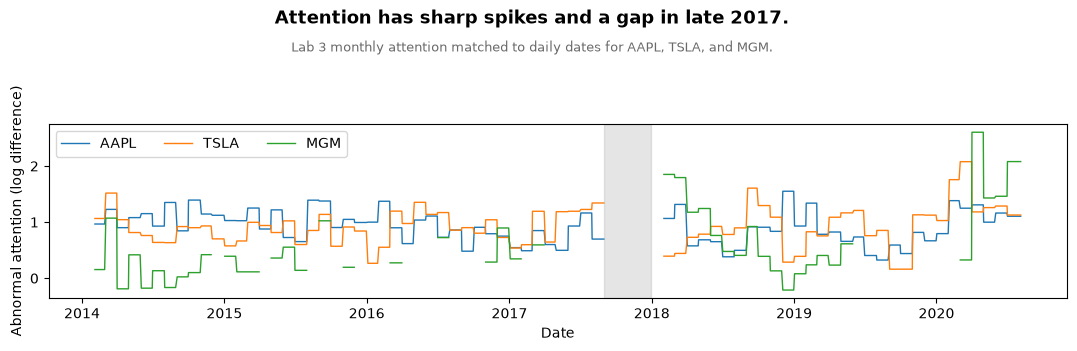

In [19]:
attention = pd.read_csv(LAB_DIR / "Data_PCLab4_Attention_Monthly.csv")
attention["Attention_Date"] = pd.to_datetime(
    attention["formation_ts"], utc=True
).dt.tz_convert("America/New_York").dt.tz_localize(None).dt.normalize()
attention["Attention"] = np.log1p(attention["att_window"]) - np.log1p(attention["att_baseline"])
assert np.allclose(attention["Attention"], attention["g"])
assert not attention.duplicated(["ticker", "Attention_Date"]).any()
assert set(attention["ticker"]) == set(model_stocks)
attention.loc[~attention["eligible"], "Attention"] = np.nan

attention_parts = []
for stock in model_stocks:
    left = enhanced_panel.loc[enhanced_panel["Stock"] == stock].sort_values("Date")
    right = attention.loc[attention["ticker"] == stock, ["Attention_Date", "Attention"]].sort_values("Attention_Date")
    joined = pd.merge_asof(left, right, left_on="Date", right_on="Attention_Date",
                           direction="backward", allow_exact_matches=False,
                           tolerance=pd.Timedelta(days=35))
    joined.loc[joined["Date"].between("2017-09-01", "2017-12-31"), "Attention"] = np.nan
    attention_parts.append(joined)
attention_panel = pd.concat(attention_parts, ignore_index=True)
available = attention_panel["Attention"].notna()
assert (attention_panel.loc[available, "Attention_Date"] < attention_panel.loc[available, "Date"]).all()
assert not attention_panel.loc[attention_panel["Date"].between("2017-09-01", "2017-12-31"), "Attention"].notna().any()

attention_rows, coverage_rows = [], []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    columns = feature_sets["+ Market + trend/risk"]
    frame = attention_panel.dropna(subset=columns + ["Attention", target, f"Target_Date_{h}d"])
    train = frame.loc[frame[f"Target_Date_{h}d"] < split_date]
    test = frame.loc[frame["Date"] >= split_date]
    assert train[f"Target_Date_{h}d"].max() < test["Date"].min()
    coverage_rows.append({"Horizon": h, "Train rows": len(train), "Test rows": len(test),
                         "Train dates": train["Date"].nunique(), "Test dates": test["Date"].nunique(),
                         "Test coverage (%)": 100 * len(test) / len(test_data[h])})
    for label, predictors in {"OLS (2.6), matched sample": columns,
                              "OLS (2.6) + attention": columns + ["Attention"]}.items():
        model = make_pipeline(MinMaxScaler(), LinearRegression())
        model.fit(train[predictors], train[target])
        attention_rows.append({"Horizon": h, "Model": label,
                               **score_forecast(test[target], model.predict(test[predictors]))})
attention_results = pd.DataFrame(attention_rows)
display(pd.DataFrame(coverage_rows).round(2))
display(attention_results.round(3))

attention_gain = attention_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)")
attention_gain["Change (percentage points)"] = attention_gain["OLS (2.6) + attention"] - attention_gain["OLS (2.6), matched sample"]
display(attention_gain.round(3))

fig, ax = plt.subplots(figsize=(11, 3.5))
for stock in ["AAPL", "TSLA", "MGM"]:
    values = attention_panel.loc[attention_panel["Stock"] == stock]
    ax.plot(values["Date"], values["Attention"], label=stock, linewidth=1)
ax.axvspan(pd.Timestamp("2017-09-01"), pd.Timestamp("2017-12-31"), color="grey", alpha=0.2)
ax.set(ylabel="Abnormal attention (log difference)", xlabel="Date")
ax.legend(ncol=3)
set_plot_titles(fig, "Attention has sharp spikes and a gap in late 2017.",
                "Lab 3 monthly attention matched to daily dates for AAPL, TSLA, and MGM.")
plt.show()


## Task 3 - Nonlinear models: Random Forest and boosted trees

### 3.1 Original six-feature comparison

#### Approach

- **Random Forest** averages many trees; **boosting** adds trees to correct earlier errors. Both allow nonlinear effects.
- We compare them with OLS and Ridge on the **original six signals**. The last 20% of training dates form tree validation; target windows cannot cross the validation or test boundary.
- We reuse per-horizon tree settings from the extended-feature playground. **Validation MSE** chooses the tree family for Task 4; trees are then refitted on all training rows.

Tree validation starts: 2017-03-08; test starts: 2018-06-20


,Horizon,Tree fit rows,Validation rows,Final refit rows,Test rows
0,5,9840,2552,12432,4280
1,20,9720,2432,12312,4160
2,60,9400,2112,11992,3840


,Horizon,Model,Setting,Validation MSE
0,5,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",13.240
1,5,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",13.226
2,20,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",46.429
3,20,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",46.631
4,60,Random Forest,"{'n_estimators': 100, 'max_depth': 2, 'min_sam...",136.971
5,60,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",137.963


,Horizon,Model,Setting,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
3,5,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",-1.631,-2.093,7.196,55.981
0,5,OLS,Original,0.536,0.084,7.119,55.117
2,5,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",-1.305,-1.766,7.184,56.262
1,5,Ridge,alpha=1.0,0.529,0.077,7.119,55.164
7,20,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",2.102,0.389,13.939,58.077
4,20,OLS,Original,0.694,-1.044,14.039,57.188
6,20,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",-1.436,-3.211,14.189,58.077
5,20,Ridge,alpha=1.0,0.671,-1.068,14.041,57.188
11,60,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",12.568,9.712,24.472,58.568
8,60,OLS,Original,1.849,-1.357,25.928,56.589


,Horizon,Features,Tree used in Task 4
0,5,Original six,Boosted trees
1,20,Original six,Random Forest
2,60,Original six,Random Forest


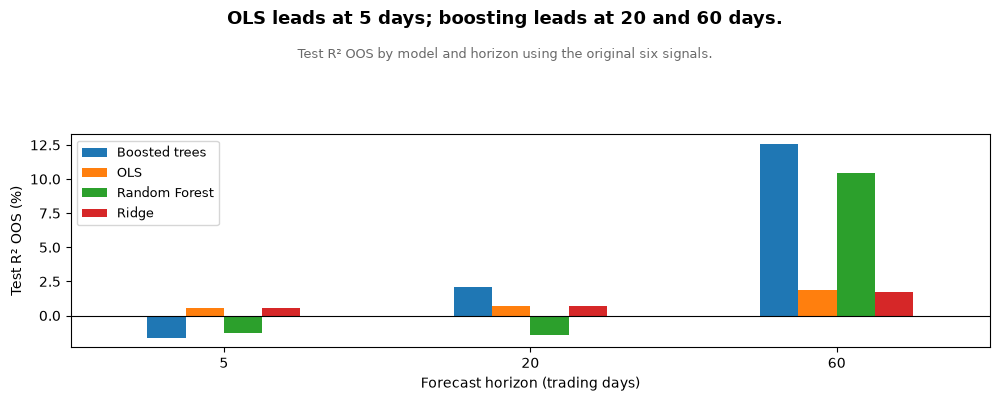

In [20]:
validation_date = pd.Timestamp(all_dates[int(split_index * 0.80)])
print(f"Tree validation starts: {validation_date.date()}; test starts: {split_date.date()}")

fitted_models, tree_validation_scores = {}, {}
model_rows, tree_tuning_rows, split_rows = [], [], []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    target_date = f"Target_Date_{h}d"
    frame = model_dfs[h]
    train, test = train_data[h], test_data[h]
    fit = frame.loc[frame[target_date] < validation_date]
    valid = frame.loc[(frame["Date"] >= validation_date) & (frame[target_date] < split_date)]
    assert len(fit) and len(valid) and len(test)
    assert fit[target_date].max() < valid["Date"].min()
    assert train[target_date].max() < test["Date"].min()
    split_rows.append({"Horizon": h, "Tree fit rows": len(fit), "Validation rows": len(valid),
                       "Final refit rows": len(train), "Test rows": len(test)})
    columns = feature_cols
    fitted_models[h], tree_validation_scores[h] = {}, {}

    # Reproduce the original Task 2 models as fixed references, with no validation tuning.
    for label, estimator in {"OLS": LinearRegression(), "Ridge": Ridge(alpha=1.0)}.items():
        model = make_pipeline(MinMaxScaler(), estimator)
        model.fit(train[columns], train[target])
        prediction = model.predict(test[columns])
        fitted_models[h][label] = model
        model_rows.append({"Horizon": h, "Model": label,
                           "Setting": "Original" if label == "OLS" else "alpha=1.0",
                           **score_forecast(test[target], prediction)})
    for label in ["Random Forest", "Boosted trees"]:
        params = TREE_CONFIGS[h][label]
        model = make_tree(label, params)
        model.fit(fit[columns], fit[target])
        loss = mean_squared_error(valid[target], model.predict(valid[columns]))
        tree_tuning_rows.append({"Horizon": h, "Model": label,
                                 "Setting": str(params), "Validation MSE": loss})
        model.fit(train[columns], train[target])
        prediction = model.predict(test[columns])
        fitted_models[h][label] = model
        tree_validation_scores[h][label] = loss
        model_rows.append({"Horizon": h, "Model": label, "Setting": str(params),
                           **score_forecast(test[target], prediction)})

model_results = pd.DataFrame(model_rows).sort_values(["Horizon", "Model"])
display(pd.DataFrame(split_rows))
display(pd.DataFrame(tree_tuning_rows).round(3))
display(model_results.round(3))

selected_tree = {h: min(["Random Forest", "Boosted trees"], key=lambda name: tree_validation_scores[h][name])
                 for h in forecast_horizons}
selection = pd.DataFrame([{
    "Horizon": h, "Features": "Original six",
    "Tree used in Task 4": selected_tree[h]
} for h in forecast_horizons])
display(selection)

fig, ax = plt.subplots(figsize=(10, 4))
model_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)").plot.bar(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(xlabel="Forecast horizon (trading days)", ylabel="Test R² OOS (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)
set_plot_titles(fig, "OLS leads at 5 days; boosting leads at 20 and 60 days.",
                "Test R² OOS by model and horizon using the original six signals.")
plt.show()


### 3.2 Extended features with Lab 3 attention

#### Approach

- We compare all four models using **12 signals**: six stock signals, three market returns, trend, volatility, and attention. They share the same attention-covered rows. Trees use playground settings; validation MSE selects the tree family.

#### Findings

- **Ridge leads at 5 and 20 days** ($R^2_{OOS}$ **0.800%** and **5.471%**); **Random Forest leads at 60 days** (**14.609%**).
- Forest is validation-selected at all horizons, but linear models beat it on the 5- and 20-day test rows. Section 3.1 has more rows, so its scores do not isolate the effect of added signals.

,Horizon,Tree fit rows,Validation rows,Final refit rows,Test rows
0,5,5897,1614,7551,4092
1,20,5792,1494,7431,3972
2,60,5476,1174,7111,3652


,Horizon,Model,Setting,Validation MSE
0,5,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",13.605
1,5,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",13.650
2,20,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",46.504
3,20,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",46.636
4,60,Random Forest,"{'n_estimators': 100, 'max_depth': 2, 'min_sam...",142.425
5,60,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",143.021


,Horizon,Model,Setting,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
3,5,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",-1.764,-2.279,7.283,53.152
0,5,OLS,Unpenalized,0.578,0.075,7.198,51.613
2,5,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",-0.898,-1.408,7.251,56.158
1,5,Ridge,alpha=1.0,0.800,0.298,7.190,51.711
7,20,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",3.770,1.454,13.577,55.136
4,20,OLS,Unpenalized,5.442,3.165,13.459,53.927
6,20,Random Forest,"{'n_estimators': 200, 'max_depth': 2, 'min_sam...",2.626,0.281,13.657,56.319
5,20,Ridge,alpha=1.0,5.471,3.195,13.457,53.902
11,60,Boosted trees,"{'n_estimators': 100, 'learning_rate': 0.03, '...",9.919,5.523,24.471,58.872
8,60,OLS,Unpenalized,14.113,9.922,23.894,60.350


,Horizon,Features,Validation-selected tree
0,5,Market + trend/risk + attention,Random Forest
1,20,Market + trend/risk + attention,Random Forest
2,60,Market + trend/risk + attention,Random Forest


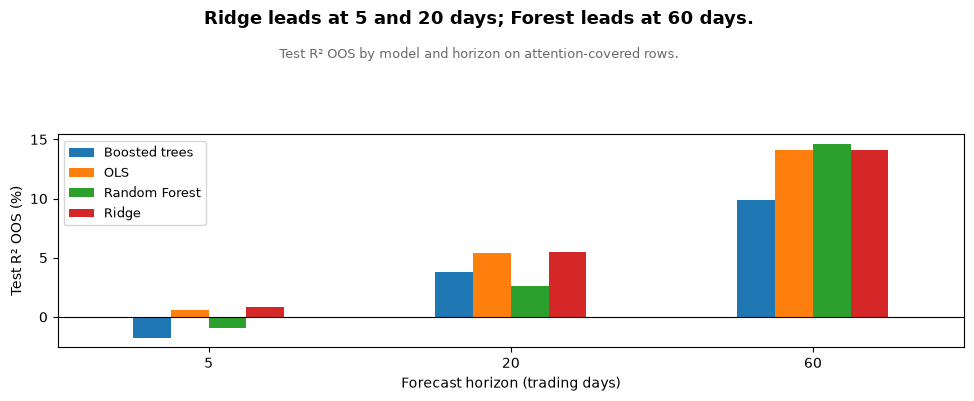

In [21]:
extended_features = all_features + ["Attention"]
extended_rows, extended_tuning_rows, extended_split_rows = [], [], []
extended_validation_scores = {}

for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    target_date = f"Target_Date_{h}d"
    frame = attention_panel.dropna(subset=extended_features + [target, target_date])
    train = frame.loc[frame[target_date] < split_date]
    test = frame.loc[frame["Date"] >= split_date]
    fit = frame.loc[frame[target_date] < validation_date]
    valid = frame.loc[(frame["Date"] >= validation_date) & (frame[target_date] < split_date)]
    assert len(fit) and len(valid) and len(test)
    assert fit[target_date].max() < valid["Date"].min()
    assert train[target_date].max() < test["Date"].min()
    assert len(train) == coverage_rows[forecast_horizons.index(h)]["Train rows"]
    assert len(test) == coverage_rows[forecast_horizons.index(h)]["Test rows"]
    extended_split_rows.append({"Horizon": h, "Tree fit rows": len(fit),
                                "Validation rows": len(valid), "Final refit rows": len(train),
                                "Test rows": len(test)})
    extended_validation_scores[h] = {}

    for label, estimator in {"OLS": LinearRegression(), "Ridge": Ridge(alpha=1.0)}.items():
        model = make_pipeline(MinMaxScaler(), estimator)
        model.fit(train[extended_features], train[target])
        prediction = model.predict(test[extended_features])
        extended_rows.append({"Horizon": h, "Model": label,
                              "Setting": "Unpenalized" if label == "OLS" else "alpha=1.0",
                              **score_forecast(test[target], prediction)})

    for label in ["Random Forest", "Boosted trees"]:
        params = TREE_CONFIGS[h][label]
        model = make_tree(label, params)
        model.fit(fit[extended_features], fit[target])
        loss = mean_squared_error(valid[target], model.predict(valid[extended_features]))
        extended_tuning_rows.append({"Horizon": h, "Model": label,
                                     "Setting": str(params), "Validation MSE": loss})
        model.fit(train[extended_features], train[target])
        prediction = model.predict(test[extended_features])
        extended_validation_scores[h][label] = loss
        extended_rows.append({"Horizon": h, "Model": label, "Setting": str(params),
                              **score_forecast(test[target], prediction)})

extended_model_results = pd.DataFrame(extended_rows).sort_values(["Horizon", "Model"])
display(pd.DataFrame(extended_split_rows))
display(pd.DataFrame(extended_tuning_rows).round(3))
display(extended_model_results.round(3))

extended_selected_tree = {
    h: min(["Random Forest", "Boosted trees"], key=lambda name: extended_validation_scores[h][name])
    for h in forecast_horizons
}
display(pd.DataFrame([{"Horizon": h, "Features": "Market + trend/risk + attention",
                       "Validation-selected tree": extended_selected_tree[h]}
                      for h in forecast_horizons]))

fig, ax = plt.subplots(figsize=(10, 4))
extended_model_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)").plot.bar(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(xlabel="Forecast horizon (trading days)", ylabel="Test R² OOS (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)
set_plot_titles(fig, "Ridge leads at 5 and 20 days; Forest leads at 60 days.",
                "Test R² OOS by model and horizon on attention-covered rows.")
plt.show()

### 3.3 Interpreting performance and relating it to the papers

#### Approach

- **Gu et al. (2020)** motivate tree models and define our $R^2_{OOS}$ measure. **Jiang et al. (2023)** predict return direction from price/volume chart images; we use numerical signals instead.

#### Findings

- On six signals, **OLS leads at 5 days** ($R^2_{OOS}$ **0.54%**); **boosting leads at 20 and 60 days** (2.10%, 12.57%). Task 4 uses the validation-selected tree.
- Our eight-stock daily results are not directly comparable with Gu et al.'s broad monthly study. The moving-average signal reflects Jiang et al.'s trend idea, but is not their CNN.

Sources: *FBD_Week5_Lecture4_2026.pdf*; Gu et al., *Empirical Asset Pricing via Machine Learning*; Jiang et al., *(Re-)Imag(in)ing Price Trends*.

## Task 4 - Performance of the AI-driven portfolio

### 4.1 Portfolio construction and trading costs

#### Approach

- Starting with **$100**, we hold **25% in each of the four stocks** with the highest predicted return. We rebalance every **5, 20, or 60 trading days**, matching the forecast horizon.
- Each strategy uses the **six-signal tree chosen on validation in section 3.1**; OLS with basic features is a reference. All use the same test dates. We assume fractional shares and trades at the forecast close, including a shortened final holding period.
- Following the assignment, switching **$50** between stocks costs **$0.005** at **1 bp**. Entry and liquidation also incur fees. We show a stricter case charging each side of a switch.

In [22]:
test_prices = price_df.set_index("Date").loc[split_date:, model_stocks]
portfolio_dates = test_prices.index
assert test_prices.notna().all().all()
portfolio_predictions = {}

for h in forecast_horizons:
    forecast_frame = panel_df.loc[panel_df["Date"] >= split_date].copy()
    for label in [selected_tree[h], "OLS"]:
        prediction = fitted_models[h][label].predict(forecast_frame[feature_cols])
        wide = forecast_frame.assign(Prediction=prediction).pivot(
            index="Date", columns="Stock", values="Prediction"
        ).reindex(index=portfolio_dates, columns=model_stocks)
        assert np.isfinite(wide).all().all()
        portfolio_predictions[h, label] = wide

def backtest_top_four(predictions, horizon, fee_rate=0.0, per_leg=False):
    """Fixed shares between rebalances; mark wealth at every daily close."""
    prices = test_prices.to_numpy()
    wealth = INITIAL_WEALTH
    shares = np.zeros(len(model_stocks))
    path, trades = [], []
    for day, date in enumerate(portfolio_dates):
        if day > 0:
            wealth = float(shares @ prices[day])
        if day % horizon == 0 and day < len(prices) - 1:
            # Stable sorting makes ties deterministic, using the CSV ticker order.
            ranks = np.argsort(-predictions.iloc[day].to_numpy(), kind="stable")[:4]
            weights = np.zeros(len(model_stocks))
            weights[ranks] = 0.25
            old_weights = shares * prices[day] / wealth
            turnover = 1.0 if day == 0 else np.abs(weights - old_weights).sum() / 2
            charged_turnover = turnover * (2 if per_leg and day > 0 else 1)
            fee = wealth * fee_rate * charged_turnover
            wealth -= fee
            shares = wealth * weights / prices[day]
            assert np.isclose(shares @ prices[day], wealth)
            assert np.count_nonzero(shares) == 4
            trades.append({"Date": date, "Holdings": ", ".join(np.array(model_stocks)[ranks]),
                           "Turnover": turnover, "Fee ($)": fee})
        if day == len(prices) - 1:
            fee = wealth * fee_rate
            wealth -= fee
            trades.append({"Date": date, "Holdings": "Liquidation", "Turnover": 1.0, "Fee ($)": fee})
        path.append(wealth)
    return pd.Series(path, index=portfolio_dates), pd.DataFrame(trades)

def describe_wealth(path):
    # Include entry costs in both total performance and drawdown.
    values = np.r_[INITIAL_WEALTH, path.to_numpy()]
    daily_returns = pd.Series(values[1:] / values[:-1] - 1)
    running_max = np.maximum.accumulate(values)
    years = (path.index[-1] - path.index[0]).days / 365.25
    return {"Final wealth ($)": path.iloc[-1],
            "Total return (%)": 100 * (path.iloc[-1] / INITIAL_WEALTH - 1),
            "CAGR (%)": 100 * ((path.iloc[-1] / INITIAL_WEALTH) ** (1 / years) - 1),
            "Annual volatility (%)": 100 * daily_returns.std() * np.sqrt(252),
            "Max drawdown (%)": 100 * (values / running_max - 1).min()}

portfolio_paths, portfolio_trades, portfolio_rows = {}, {}, []
for h in forecast_horizons:
    for label, predictor, fee, per_leg in [
        ("AI gross", selected_tree[h], 0.0, False),
        ("AI net (slide fees)", selected_tree[h], FEE_RATE, False),
        ("AI net (per-leg fees)", selected_tree[h], FEE_RATE, True),
        ("OLS gross", "OLS", 0.0, False)
    ]:
        path, trades = backtest_top_four(portfolio_predictions[h, predictor], h, fee, per_leg)
        portfolio_paths[h, label], portfolio_trades[h, label] = path, trades
        portfolio_rows.append({"Horizon": h, "Strategy": label, "Model": predictor,
                               **describe_wealth(path), "Fees paid ($)": trades["Fee ($)"].sum(),
                               "Entry/rebalances": len(trades) - 1})
    assert (portfolio_paths[h, "AI net (slide fees)"] <= portfolio_paths[h, "AI gross"] + 1e-8).all()
    assert (portfolio_paths[h, "AI net (per-leg fees)"] <= portfolio_paths[h, "AI net (slide fees)"] + 1e-8).all()

# Reconstruct gross terminal wealth from non-overlapping holding-period returns.
for h in forecast_horizons:
    prediction = portfolio_predictions[h, selected_tree[h]]
    reconstructed = INITIAL_WEALTH
    for start in range(0, len(test_prices) - 1, h):
        end = min(start + h, len(test_prices) - 1)
        chosen = np.argsort(-prediction.iloc[start].to_numpy(), kind="stable")[:4]
        relatives = test_prices.iloc[end].to_numpy() / test_prices.iloc[start].to_numpy()
        reconstructed *= relatives[chosen].mean()
    assert np.isclose(reconstructed, portfolio_paths[h, "AI gross"].iloc[-1])

portfolio_results = pd.DataFrame(portfolio_rows)
print(f"Common test period: {portfolio_dates[0].date()} to {portfolio_dates[-1].date()}")
display(portfolio_results.round(3))
display(portfolio_trades[20, "AI net (slide fees)"].head(8).round({"Turnover": 4, "Fee ($)": 4}))


Common test period: 2018-06-20 to 2020-08-11


,Horizon,Strategy,Model,Final wealth ($),Total return (%),CAGR (%),Annual volatility (%),Max drawdown (%),Fees paid ($),Entry/rebalances
0,5,AI gross,Boosted trees,180.321,80.321,31.656,42.394,-56.540,0.000,108
1,5,AI net (slide fees),Boosted trees,179.573,79.573,31.401,42.394,-56.546,0.519,108
2,5,AI net (per-leg fees),Boosted trees,178.864,78.864,31.158,42.394,-56.552,1.007,108
3,5,OLS gross,OLS,198.141,98.141,37.572,38.428,-54.243,0.000,108
4,20,AI gross,Random Forest,160.427,60.427,24.669,40.714,-45.192,0.000,27
5,20,AI net (slide fees),Random Forest,160.294,60.294,24.620,40.714,-45.196,0.093,27
6,20,AI net (per-leg fees),Random Forest,160.192,60.192,24.583,40.714,-45.200,0.160,27
7,20,OLS gross,OLS,166.024,66.024,26.679,31.828,-34.370,0.000,27
8,60,AI gross,Random Forest,169.569,69.569,27.933,36.237,-45.689,0.000,9
9,60,AI net (slide fees),Random Forest,169.506,69.506,27.911,36.237,-45.690,0.047,9


,Date,Holdings,Turnover,Fee ($)
0,2018-06-20,"TSLA, AAPL, BA, T",1.0000,0.0100
1,2018-07-19,"IBM, AAPL, BA, T",0.2512,0.0025
2,2018-08-16,"AAPL, BA, T, MGM",0.2635,0.0027
3,2018-09-14,"TSLA, AAPL, BA, T",0.2513,0.0026
4,2018-10-12,"TSLA, MGM, AAPL, BA",0.2711,0.0027
5,2018-11-09,"TSLA, IBM, AAPL, BA",0.2938,0.0031
6,2018-12-11,"AAPL, AMZN, IBM, BA",0.2941,0.0029
7,2019-01-10,"AAPL, TSLA, BA, MGM",0.5233,0.0052


### 4.2 Comparison with 1,000 random buy-and-hold portfolios

#### Approach

- We draw **1,000 random eight-stock portfolios** and hold them to the test end. The six displayed net paths are three tree strategies, one actual random portfolio near median final wealth, equal-weight stocks, and the S&P 500 price index.
- Sharpe is annualized mean daily return divided by annualized volatility, assuming a **0% risk-free rate**. Buy-and-hold paths pay 1 bp on entry and exit.
- We maximize Sharpe over long-only buy-and-hold weights on the **same test period**. This is a hindsight benchmark.

,Benchmark,Final wealth ($),Total return (%),CAGR (%),Annual volatility (%),Max drawdown (%)
0,Equal-weight buy-and-hold,152.849,52.849,21.886,31.339,-41.482
1,S&P 500 price index,120.466,20.466,9.074,25.402,-33.925


,Statistic,Random gross final ($),Random net final ($)
0,Minimum,82.01,82.00
1,5th percentile,103.61,103.59
2,Median,150.31,150.28
3,95th percentile,222.73,222.68
4,Maximum,292.20,292.14


,Horizon,AI gross final ($),AI net final ($),Gross percentile,Net percentile
0,5,180.32,179.57,78.5,78.3
1,20,160.43,160.29,61.2,61.1
2,60,169.57,169.51,69.9,69.9


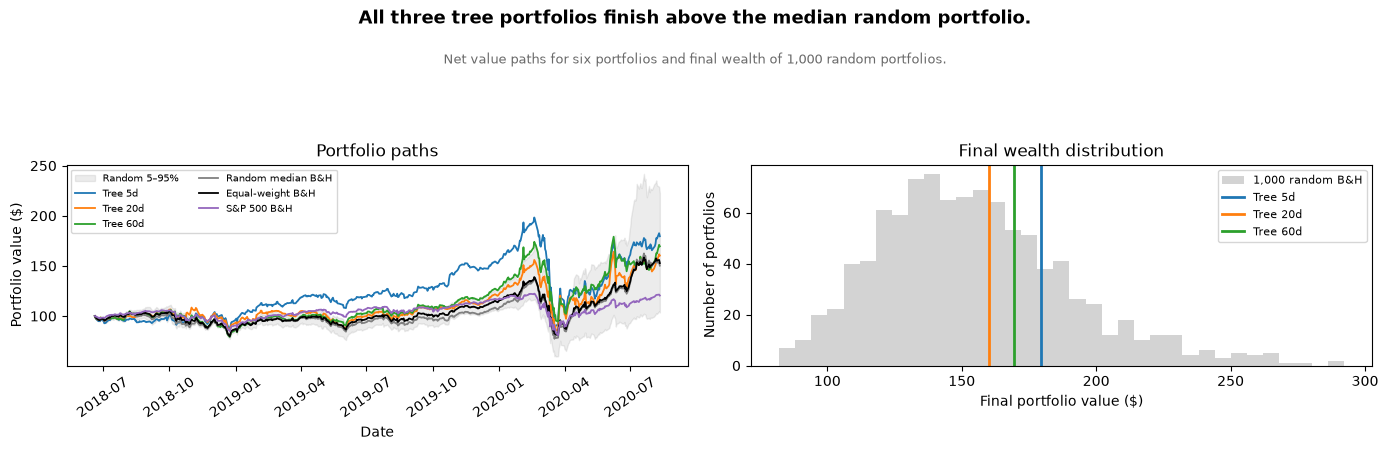

Hindsight maximum Sharpe (long-only buy-and-hold): 1.427


,Portfolio,Annual return (%),Annual volatility (%),Sharpe ratio
0,Tree 5d,36.460,42.394,0.860
1,Tree 20d,30.275,40.714,0.744
2,Tree 60d,31.262,36.237,0.863
3,Random median B&H,24.450,32.811,0.745
4,Equal-weight B&H,24.757,31.340,0.790
5,S&P 500 B&H,11.928,25.403,0.470


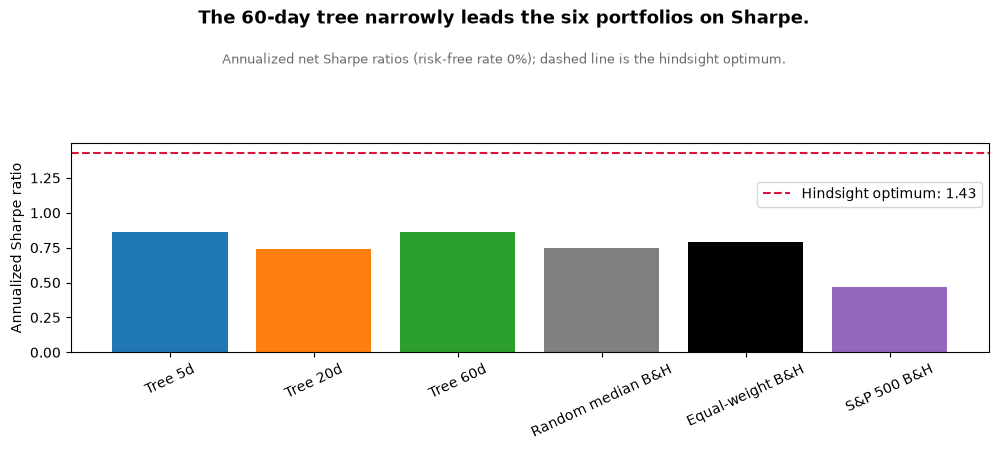

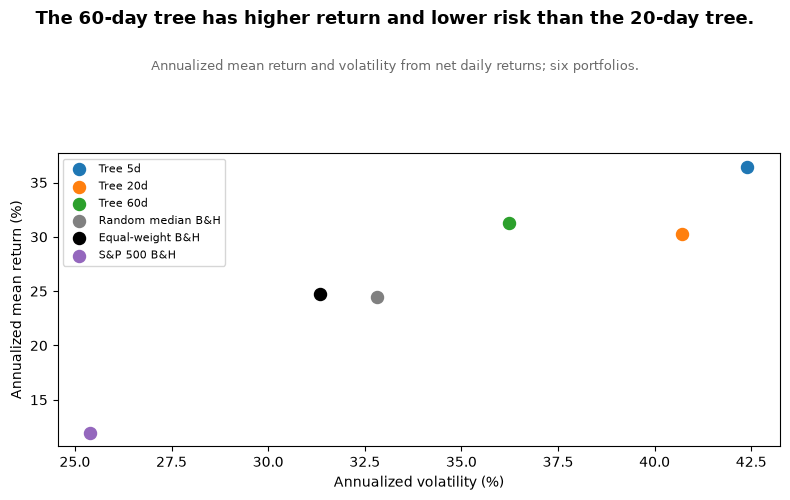

In [23]:
rng = np.random.default_rng(RANDOM_SEED)
random_weights = rng.dirichlet(np.ones(len(model_stocks)), size=N_RANDOM_PORTFOLIOS)
assert (random_weights >= 0).all() and np.allclose(random_weights.sum(axis=1), 1)
price_relatives = test_prices / test_prices.iloc[0]
random_paths = INITIAL_WEALTH * price_relatives.to_numpy() @ random_weights.T
assert np.allclose(random_paths[0], INITIAL_WEALTH)
random_terminal = random_paths[-1]
random_net_paths = random_paths * (1 - FEE_RATE)
random_net_paths[-1] *= 1 - FEE_RATE
random_net_terminal = random_net_paths[-1]
equal_weight_path = INITIAL_WEALTH * price_relatives.mean(axis=1)
market_prices = price_df.set_index("Date").loc[portfolio_dates, "sp500"]
market_path = INITIAL_WEALTH * market_prices / market_prices.iloc[0]

benchmark_rows = [
    {"Benchmark": "Equal-weight buy-and-hold", **describe_wealth(equal_weight_path)},
    {"Benchmark": "S&P 500 price index", **describe_wealth(market_path)}
]
display(pd.DataFrame(benchmark_rows).round(3))
display(pd.DataFrame({"Statistic": ["Minimum", "5th percentile", "Median", "95th percentile", "Maximum"],
                      "Random gross final ($)": np.quantile(random_terminal, [0, .05, .5, .95, 1]),
                      "Random net final ($)": np.quantile(random_net_terminal, [0, .05, .5, .95, 1])}).round(2))

percentile_rows = []
for h in forecast_horizons:
    gross = portfolio_paths[h, "AI gross"].iloc[-1]
    net = portfolio_paths[h, "AI net (slide fees)"].iloc[-1]
    percentile_rows.append({"Horizon": h, "AI gross final ($)": gross, "AI net final ($)": net,
                           "Gross percentile": 100 * np.mean(random_terminal < gross),
                           "Net percentile": 100 * np.mean(random_net_terminal < net)})
portfolio_percentiles = pd.DataFrame(percentile_rows)
display(portfolio_percentiles.round(2))

# Use one actual random portfolio whose final value is closest to the median.
median_random_index = np.abs(random_net_terminal - np.median(random_net_terminal)).argmin()
median_random_path = pd.Series(random_net_paths[:, median_random_index], index=portfolio_dates)
equal_weight_net = equal_weight_path * (1 - FEE_RATE)
market_net = market_path * (1 - FEE_RATE)
equal_weight_net.iloc[-1] *= 1 - FEE_RATE
market_net.iloc[-1] *= 1 - FEE_RATE
comparison_paths = {
    "Tree 5d": portfolio_paths[5, "AI net (slide fees)"],
    "Tree 20d": portfolio_paths[20, "AI net (slide fees)"],
    "Tree 60d": portfolio_paths[60, "AI net (slide fees)"],
    "Random median B&H": median_random_path,
    "Equal-weight B&H": equal_weight_net,
    "S&P 500 B&H": market_net
}
comparison_colors = {"Tree 5d": "tab:blue", "Tree 20d": "tab:orange",
                     "Tree 60d": "tab:green", "Random median B&H": "grey",
                     "Equal-weight B&H": "black", "S&P 500 B&H": "tab:purple"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
lower, upper = np.quantile(random_net_paths, [0.05, 0.95], axis=1)
axes[0].fill_between(portfolio_dates, lower, upper, alpha=0.15, color="grey", label="Random 5–95%")
for label, path in comparison_paths.items():
    axes[0].plot(portfolio_dates, path, label=label, color=comparison_colors[label], linewidth=1.3)
axes[0].set(xlabel="Date", ylabel="Portfolio value ($)", title="Portfolio paths")
axes[0].legend(fontsize=7, ncol=2)
axes[1].hist(random_net_terminal, bins=35, color="lightgrey", label="1,000 random B&H")
for h in forecast_horizons:
    label = f"Tree {h}d"
    axes[1].axvline(comparison_paths[label].iloc[-1], label=label, linewidth=2,
                   color=comparison_colors[label])
axes[1].set(xlabel="Final portfolio value ($)", ylabel="Number of portfolios",
            title="Final wealth distribution")
axes[1].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=35)
set_plot_titles(fig, "All three tree portfolios finish above the median random portfolio.",
                "Net value paths for six portfolios and final wealth of 1,000 random portfolios.")
plt.show()

def annual_risk_return(path):
    values = np.asarray(path)
    daily = np.diff(np.r_[INITIAL_WEALTH, values]) / np.r_[INITIAL_WEALTH, values[:-1]]
    annual_return = 252 * daily.mean()
    annual_risk = np.sqrt(252) * daily.std(ddof=1)
    return annual_return, annual_risk, annual_return / annual_risk

risk_return_rows = []
for label, path in comparison_paths.items():
    annual_return, annual_risk, sharpe = annual_risk_return(path)
    risk_return_rows.append({"Portfolio": label, "Annual return (%)": 100 * annual_return,
                             "Annual volatility (%)": 100 * annual_risk, "Sharpe ratio": sharpe})
risk_return = pd.DataFrame(risk_return_rows)

def net_buy_hold_path(weights):
    path = INITIAL_WEALTH * (price_relatives.to_numpy() @ weights) * (1 - FEE_RATE)
    path[-1] *= 1 - FEE_RATE
    return path

# Hindsight optimum within long-only, fixed-initial-weight buy-and-hold portfolios.
random_sharpes = np.array([annual_risk_return(random_net_paths[:, j])[2]
                           for j in range(N_RANDOM_PORTFOLIOS)])
starts = np.vstack([np.ones(len(model_stocks)) / len(model_stocks), np.eye(len(model_stocks)),
                    random_weights[random_sharpes.argmax()]])
solutions = [minimize(lambda w: -annual_risk_return(net_buy_hold_path(w))[2], start,
                      method="SLSQP", bounds=[(0, 1)] * len(model_stocks),
                      constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
                      options={"ftol": 1e-10}) for start in starts]
optimal = min((result for result in solutions if result.success), key=lambda result: result.fun)
optimal_sharpe = -optimal.fun
assert optimal_sharpe >= random_sharpes.max() - 1e-6
print(f"Hindsight maximum Sharpe (long-only buy-and-hold): {optimal_sharpe:.3f}")
display(risk_return.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(risk_return["Portfolio"], risk_return["Sharpe ratio"],
       color=[comparison_colors[label] for label in risk_return["Portfolio"]])
ax.axhline(optimal_sharpe, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Hindsight optimum: {optimal_sharpe:.2f}")
ax.set(ylabel="Annualized Sharpe ratio")
ax.tick_params(axis="x", rotation=25)
ax.legend(loc="upper right", bbox_to_anchor=(1, 0.85))
set_plot_titles(fig, "The 60-day tree narrowly leads the six portfolios on Sharpe.",
                "Annualized net Sharpe ratios (risk-free rate 0%); dashed line is the hindsight optimum.")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for row in risk_return.itertuples(index=False):
    ax.scatter(row[2], row[1], color=comparison_colors[row[0]], s=75, label=row[0])
ax.set(xlabel="Annualized volatility (%)", ylabel="Annualized mean return (%)")
ax.legend(fontsize=8)
set_plot_titles(fig, "The 60-day tree has higher return and lower risk than the 20-day tree.",
                "Annualized mean return and volatility from net daily returns; six portfolios.")
plt.show()


### 4.3 What we can conclude

#### Findings

- The **20-day tree portfolio** ends at **$160.43 gross** and **$160.29 net**, against **$152.85** for equal-weight buy-and-hold and **$120.47** for the S&P 500 price index (both gross).
- Random buy-and-hold has a **$150.31 gross median** and **$103.61–$222.73** gross 5th–95th percentile range. The 20-day strategy is at the **61st net percentile**.
- The 5- and 60-day trees end at **$179.57** and **$169.51 net**. Gross OLS portfolios beat the trees. Charging both sides of switches gives **$160.19** at 20 days.
- The 60-day tree leads Sharpe (**0.863**), below the hindsight maximum (**1.427**). It has higher annual return and lower volatility than the 20-day tree.

#### Limitations

- Eight stocks, one test period, unverified dividends, and omitted trading frictions limit the result. The wider tree search followed an earlier look at test results, so these comparisons are **exploratory**.

#### Reproducibility

- Inputs are local CSVs; random seed is **42**. Add the group's actual time spent before submission.

## Playground - Wider tree tuning on the validation set

#### Approach

- We test **24 settings per tree family and horizon** on the 12-signal validation data, varying tree count, depth, leaf size, and either feature share or learning rate.
- Validation $R^2_{OOS}$ selects the settings reused in Task 3. The test comparison uses section 3.2's rows.

Evaluated 144 configurations


,Horizon,Model,max_depth,max_features,min_samples_leaf,n_estimators,Validation MSE,Validation RMSE,Validation R²_OOS (%),Direction accuracy (%),learning_rate
100,60,Random Forest,2.0,1.0,20,100,142.425,11.934,3.553,53.918,NaN
49,20,Random Forest,2.0,0.8,20,200,46.504,6.819,3.488,57.430,NaN
5,5,Random Forest,2.0,1.0,20,200,13.605,3.688,3.445,55.019,NaN
13,5,Random Forest,4.0,1.0,20,200,13.608,3.689,3.419,55.328,NaN
9,5,Random Forest,4.0,0.8,20,200,13.611,3.689,3.399,55.328,NaN
102,60,Random Forest,2.0,1.0,100,100,142.682,11.945,3.379,54.855,NaN
99,60,Random Forest,2.0,0.8,100,200,142.745,11.948,3.336,53.918,NaN
53,20,Random Forest,2.0,1.0,20,200,46.607,6.827,3.273,57.430,NaN
48,20,Random Forest,2.0,0.8,20,100,46.628,6.828,3.230,56.894,NaN
74,20,Boosted trees,1.0,NaN,100,100,46.636,6.829,3.214,57.564,0.03


,Horizon,Model,Best configuration,Validation R²_OOS (%),Used in Task 3
0,5,Boosted trees,"trees=100, depth=3, leaf=20, learning rate=0.03",3.121,True
1,5,Random Forest,"trees=200, depth=2, leaf=20, feature share=1.0",3.445,True
2,20,Boosted trees,"trees=100, depth=1, leaf=100, learning rate=0.03",3.214,True
3,20,Random Forest,"trees=200, depth=2, leaf=20, feature share=0.8",3.488,True
4,60,Boosted trees,"trees=100, depth=1, leaf=20, learning rate=0.03",3.149,True
5,60,Random Forest,"trees=100, depth=2, leaf=20, feature share=1.0",3.553,True


,Horizon,Model,R2_OOS (%),Test R2 (%),RMSE (pp),Correct sign (%)
7,5,Boosted trees,-1.764,-2.279,7.283,53.152
0,5,OLS,0.578,0.075,7.198,51.613
6,5,Random Forest,-0.898,-1.408,7.251,56.158
1,5,Ridge,0.800,0.298,7.190,51.711
9,20,Boosted trees,3.770,1.454,13.577,55.136
2,20,OLS,5.442,3.165,13.459,53.927
8,20,Random Forest,2.626,0.281,13.657,56.319
3,20,Ridge,5.471,3.195,13.457,53.902
11,60,Boosted trees,9.919,5.523,24.471,58.872
4,60,OLS,14.113,9.922,23.894,60.350


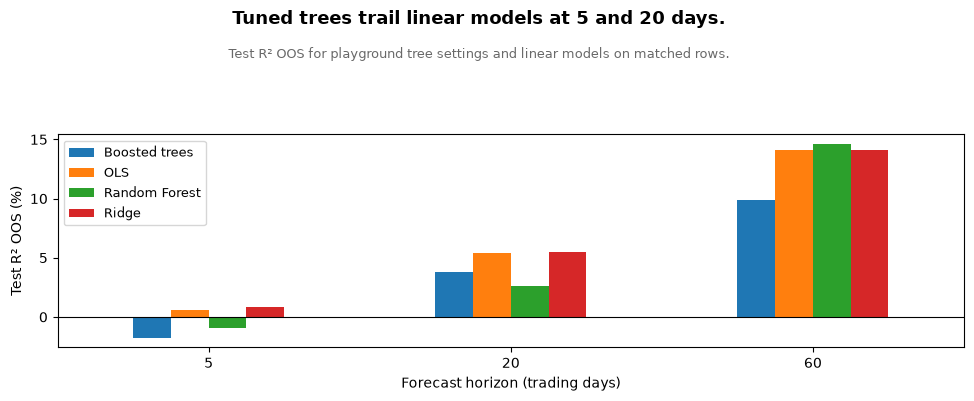

In [24]:
tree_playground_rows = []
playground_grids = {
    "Random Forest": {
        "n_estimators": [100, 200], "max_depth": [2, 4, None],
        "min_samples_leaf": [20, 100], "max_features": [0.8, 1.0]
    },
    "Boosted trees": {
        "n_estimators": [100, 200], "learning_rate": [0.03, 0.1],
        "max_depth": [1, 2, 3], "min_samples_leaf": [20, 100]
    }
}

for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    target_date = f"Target_Date_{h}d"
    frame = attention_panel.dropna(subset=extended_features + [target, target_date])
    fit = frame.loc[frame[target_date] < validation_date]
    valid = frame.loc[(frame["Date"] >= validation_date) & (frame[target_date] < split_date)]
    assert len(fit) and len(valid)
    assert fit[target_date].max() < valid["Date"].min()

    for family, grid in playground_grids.items():
        for params in ParameterGrid(grid):
            if family == "Random Forest":
                model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=1, **params)
            else:
                model = GradientBoostingRegressor(random_state=RANDOM_SEED, **params)
            model.fit(fit[extended_features], fit[target])
            prediction = model.predict(valid[extended_features])
            tree_playground_rows.append({
                "Horizon": h, "Model": family, "Parameters": params, **params,
                "Validation MSE": mean_squared_error(valid[target], prediction),
                "Validation RMSE": np.sqrt(mean_squared_error(valid[target], prediction)),
                "Validation R²_OOS (%)": 100 * r2_oos(valid[target], prediction),
                "Direction accuracy (%)": 100 * np.mean(np.sign(valid[target]) == np.sign(prediction))
            })

tree_playground_results = pd.DataFrame(tree_playground_rows)
playground_top = (tree_playground_results.sort_values("Validation R²_OOS (%)", ascending=False)
                  .groupby(["Horizon", "Model"], group_keys=False).head(3))
playground_best = (tree_playground_results.sort_values("Validation R²_OOS (%)", ascending=False)
                   .groupby(["Horizon", "Model"], group_keys=False).head(1)
                   .sort_values(["Horizon", "Model"]))
print(f"Evaluated {len(tree_playground_results)} configurations")
display(playground_top.drop(columns="Parameters").round(3))
best_configs = []
for _, row in playground_best.iterrows():
    params = row["Parameters"]
    setting = (f"trees={params['n_estimators']}, depth={params['max_depth']}, "
               f"leaf={params['min_samples_leaf']}, "
               + (f"feature share={params['max_features']}" if row["Model"] == "Random Forest"
                  else f"learning rate={params['learning_rate']}"))
    best_configs.append({"Horizon": row["Horizon"], "Model": row["Model"],
                         "Best configuration": setting,
                         "Validation R²_OOS (%)": row["Validation R²_OOS (%)"],
                         "Used in Task 3": params == TREE_CONFIGS[row["Horizon"]][row["Model"]]})
display(pd.DataFrame(best_configs).round(3))

tuned_tree_rows = []
for h in forecast_horizons:
    target = f"Future_Return_{h}d"
    target_date = f"Target_Date_{h}d"
    frame = attention_panel.dropna(subset=extended_features + [target, target_date])
    train = frame.loc[frame[target_date] < split_date]
    test = frame.loc[frame["Date"] >= split_date]
    assert len(test) == coverage_rows[forecast_horizons.index(h)]["Test rows"]
    for family in playground_grids:
        params = playground_best.loc[
            (playground_best["Horizon"] == h) & (playground_best["Model"] == family),
            "Parameters"
        ].iloc[0]
        if family == "Random Forest":
            model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=1, **params)
        else:
            model = GradientBoostingRegressor(random_state=RANDOM_SEED, **params)
        model.fit(train[extended_features], train[target])
        tuned_tree_rows.append({"Horizon": h, "Model": family, "Setting": str(params),
                                **score_forecast(test[target], model.predict(test[extended_features]))})

playground_test_results = pd.concat([
    extended_model_results.loc[extended_model_results["Model"].isin(["OLS", "Ridge"])],
    pd.DataFrame(tuned_tree_rows)
], ignore_index=True).sort_values(["Horizon", "Model"])
display(playground_test_results.drop(columns="Setting").round(3))

fig, ax = plt.subplots(figsize=(10, 4))
playground_test_results.pivot(index="Horizon", columns="Model", values="R2_OOS (%)").plot.bar(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(xlabel="Forecast horizon (trading days)", ylabel="Test R² OOS (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)
set_plot_titles(fig, "Tuned trees trail linear models at 5 and 20 days.",
                "Test R² OOS for playground tree settings and linear models on matched rows.")
plt.show()

#### Findings

- Forest leads validation at all three horizons.
- On matched test rows, linear models lead at 5/20 days; Forest leads at 60 days.
- Earlier test results informed the search, so this comparison is **exploratory**.